In [1]:
import networkx as nx
import random
import matplotlib.pyplot as plt
import urllib
import pandas as pd
import statistics

In [2]:
SEED = 37
random.seed(SEED)

In [3]:
def count_conflicts(G, colours):
    """
    Return the number of conflicting edges in the graph
    """
    conflicts = 0
    for u, v in G.edges():
        if colours[u] == colours[v]:
            conflicts += 1
    return conflicts


def initialize_conflict_state(G, colours):
    """Initialize conflict tracking structures

    Returns:
        node_conflicts: dict mapping nodes to numbers of adjacent conflicting edges
        conflicted_nodes: set of nodes currently in conflict
        edge_conflicts: total number of conflicting edges in the graph
    """
    node_conflicts = {node: 0 for node in G.nodes()}
    for u, v in G.edges():
        if colours[u] == colours[v]:
            node_conflicts[u] += 1
            node_conflicts[v] += 1

    conflicted_nodes = {node for node, c in node_conflicts.items() if c > 0}
    edge_conflicts = sum(node_conflicts.values()) // 2
    return node_conflicts, conflicted_nodes, edge_conflicts


def choose_min_conflict_colour(node, colours, G, num_colours):
    """Choose a colour for a node to change to that minimises conflicts"""
    neighbour_freq = {}
    for n in G.neighbors(node):
        c = colours[n]
        neighbour_freq[c] = neighbour_freq.get(c, 0) + 1

    best = []
    best_value = float("inf")
    for c in range(num_colours):
        value = neighbour_freq.get(c, 0)
        if value < best_value:
            best_value = value
            best = [c]
        elif value == best_value:
            best.append(c)
    return random.choice(best)  # if multiple tie, pick one randomly


def update_node(
    node,
    colours,
    G,
    num_colours,
    node_conflicts,
    conflicted_nodes,
    random_move_prob=0.08,
):
    """Update one conflicted node and maintain conflict state
    Picks new colour for node, applies recolour, updates node_conflicts for node and its neighbours, updates conflicted_nodes membership

    Returns:
        int: Change in number of conflicting edges adjacent to node after the recolour
        This is used to update the global conflict count
    """
    if node_conflicts[node] == 0:
        conflicted_nodes.discard(node)
        return 0

    old_colour = colours[node]
    if random.random() < random_move_prob:
        new_colour = random.randrange(num_colours)
    else:
        new_colour = choose_min_conflict_colour(node, colours, G, num_colours)

    if new_colour == old_colour:
        choices = [c for c in range(num_colours) if c != old_colour]
        if not choices:
            return 0
        new_colour = random.choice(choices)

    old_incident = node_conflicts[node]
    colours[node] = new_colour

    for n in G.neighbors(node):
        neighbour_colour = colours[n]
        was_conflict = neighbour_colour == old_colour
        now_conflict = neighbour_colour == new_colour

        if was_conflict and not now_conflict:
            node_conflicts[node] -= 1
            node_conflicts[n] -= 1
        elif not was_conflict and now_conflict:
            node_conflicts[node] += 1
            node_conflicts[n] += 1

        if node_conflicts[n] > 0:
            conflicted_nodes.add(n)
        else:
            conflicted_nodes.discard(n)

    if node_conflicts[node] > 0:
        conflicted_nodes.add(node)
    else:
        conflicted_nodes.discard(node)

    return node_conflicts[node] - old_incident


def min_conflicts_for_k(G, k, steps=4000, restarts=30, random_move_prob=0.08):
    """Run a local search for the minimum number of conflicts for k colours
    For each restart, initialises a random colouring and performs up to "steps" node updates, always selecting a currently conflicted node.
    Keeps track of best results across each restart and stops early if a 0 conflict colouring is found.

    Returns:
        tuple:
            colours: best colouring found, maps node to colour
            best conf (int): number of conflicting edges in the returned colouring
            trace (list[int]): conflict count history for the restart that produced the returned colouring
    """
    best_colours = None
    best_conf = float("inf")
    best_trace = []

    for _ in range(restarts):
        colours = {node: random.randint(0, k - 1) for node in G.nodes()}
        node_conflicts, conflicted_nodes, edge_conflicts = initialize_conflict_state(
            G, colours
        )
        trace = [
            edge_conflicts
        ]  # stores conflict count after each step in this restart, first entry is initial conflicts

        if edge_conflicts == 0:
            return colours, 0, trace

        for _ in range(steps):
            if not conflicted_nodes:  # if no more conflicted nodes, valid solution
                return colours, 0, trace

            node = random.choice(tuple(conflicted_nodes))
            edge_conflicts += update_node(
                node,
                colours,
                G,
                k,
                node_conflicts,
                conflicted_nodes,
                random_move_prob=random_move_prob,
            )
            trace.append(edge_conflicts)  # records progress over steps

            if edge_conflicts == 0:
                return colours, 0, trace

        # keep this restart if it's the best one so far
        if edge_conflicts < best_conf:
            best_conf = edge_conflicts
            best_colours = colours.copy()
            best_trace = trace

    # if no perfect solution found, returns the best attempt
    return best_colours, best_conf, best_trace

In [4]:
def planted_k_chromatic_graph(n=500, k=20, p_inter=0.12, seed=37):
    """Generate a graph with a known colouring with at least k colours
    1. Create n nodes and split them into k classes.
    2. Randomly add edges with probability p_inter between different classes.
    3. Select one node from each class and connect them all, enforces minimum of k colouring.

    Returns:
        G: graph
        planted_colours: dict mapping nodes to colours
        k: input chromatic number
    """
    rng = random.Random(seed)
    G = nx.Graph()
    G.add_nodes_from(range(n))

    classes = [
        [] for _ in range(k)
    ]  # create k empty classes, then assign nodes to each
    for i, node in enumerate(G.nodes()):
        classes[i % k].append(node)
    rng.shuffle(classes)

    node_to_class = {}
    for class_id, group in enumerate(classes):
        for node in group:
            node_to_class[node] = class_id

    # add edges between classes only
    nodes = list(G.nodes())
    for i in range(len(nodes)):
        u = nodes[i]
        cu = node_to_class[u]
        for j in range(i + 1, len(nodes)):
            v = nodes[j]
            if (
                node_to_class[v] != cu and rng.random() < p_inter
            ):  # check they are different colours, add edge with prob p_inter
                G.add_edge(u, v)

    reps = [group[0] for group in classes if group]  # pick one node from each class
    for i in range(len(reps)):
        for j in range(i + 1, len(reps)):
            G.add_edge(reps[i], reps[j])  # connect them all

    # return planted colouring as node -> class (colour)
    planted_colours = {node: node_to_class[node] for node in G.nodes()}
    return G, planted_colours, k


G, planted_colours, planted_k = planted_k_chromatic_graph(
    n=1000, k=12, p_inter=0.05, seed=SEED
)

highest_degree = max(dict(G.degree()).values())
max_colours = planted_k + 6

print("Nodes:", G.number_of_nodes(), "Edges:", G.number_of_edges())
print("Highest degree:", highest_degree)
print("Planted k:", planted_k, "Search k:", planted_k, "to", max_colours)

Nodes: 1000 Edges: 22908
Highest degree: 69
Planted k: 12 Search k: 12 to 18


In [ ]:
timeline_steps = []
timeline_conflicts = []
timeline_k_values = []

best_colours = None
best_k = None
best_conf = float("inf")

global_step = 0
start_k = planted_k

for k in range(start_k, max_colours + 1):
    candidate, conflicts, trace = min_conflicts_for_k(
        G, k, steps=10000, restarts=50, random_move_prob=0.08
    )

    for value in trace:
        timeline_steps.append(global_step)
        timeline_conflicts.append(value)
        timeline_k_values.append(k)
        global_step += 1

    if candidate is not None and conflicts < best_conf:
        best_conf = conflicts
        best_colours = candidate.copy()
        best_k = k

    if conflicts == 0:
        break

colours = best_colours
if best_conf == 0:
    print("Exact colouring found at k =", best_k)
else:
    print("Best found: k =", best_k, "with", best_conf, "conflicts")

Exact colouring found at k = 16


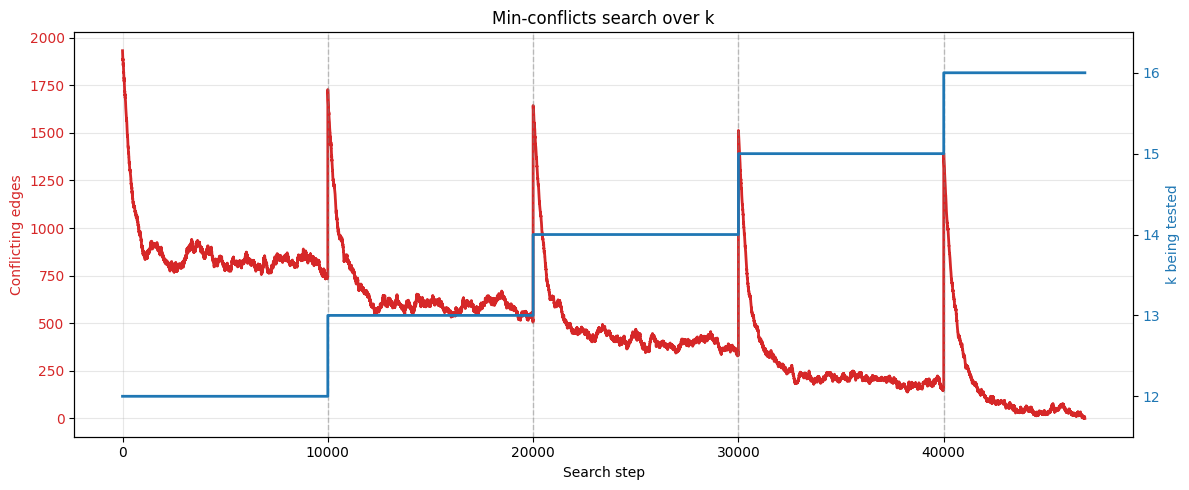

In [6]:
k_change_positions = [
    timeline_steps[i]
    for i in range(1, len(timeline_steps))
    if timeline_k_values[i] != timeline_k_values[i - 1]
]
k_ticks = sorted(set(timeline_k_values))

fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(timeline_steps, timeline_conflicts, color="tab:red", linewidth=2)
ax1.set_xlabel("Search step")
ax1.set_ylabel("Conflicting edges", color="tab:red")
ax1.tick_params(axis="y", labelcolor="tab:red")
ax1.set_title("Min-conflicts search over k")
ax1.grid(True, alpha=0.3)

for x in k_change_positions:
    ax1.axvline(x=x, color="gray", linestyle="--", linewidth=1, alpha=0.45)

ax2 = ax1.twinx()
ax2.step(timeline_steps, timeline_k_values, where="post", color="tab:blue", linewidth=2)
ax2.set_ylabel("k being tested", color="tab:blue")
ax2.set_yticks(k_ticks)
ax2.set_ylim(min(k_ticks) - 0.5, max(k_ticks) + 0.5)
ax2.tick_params(axis="y", labelcolor="tab:blue")

plt.tight_layout()
plt.show()

In [7]:
planted_conflicts = count_conflicts(G, planted_colours)
search_conflicts = count_conflicts(G, colours)

print("Planted colouring conflicts:", planted_conflicts)
print("Returned colouring conflicts:", search_conflicts)
print("Best k used:", best_k)

Planted colouring conflicts: 0
Returned colouring conflicts: 0
Best k used: 16


In [ ]:
num_trials = 10
trial_results = []

for trial in range(num_trials):
    trial_best_conf = float("inf")
    trial_best_k = None

    for k in range(planted_k, max_colours + 1):
        candidate, conflicts, _ = min_conflicts_for_k(
            G, k, steps=10000, restarts=50, random_move_prob=0.08
        )

        if conflicts < trial_best_conf:
            trial_best_conf = conflicts
            trial_best_k = k

        if conflicts == 0:
            break

    trial_results.append((trial_best_k, trial_best_conf))

k_values = [k for k, _ in trial_results]
conf_values = [c for _, c in trial_results]
exact_count = sum(1 for c in conf_values if c == 0)

print("Trials:", num_trials)
print(
    "Exact 0-conflict runs:",
    exact_count,
    "(",
    round(100 * exact_count / num_trials, 1),
    "%)",
)
print("Best conflicts across trials:", min(conf_values))
print("Mean conflicts:", round(sum(conf_values) / len(conf_values), 2))
print("Best k across trials:", min(k_values))
print("Mean k:", round(sum(k_values) / len(k_values), 2))
print("Per-trial (k, conflicts):", trial_results)

Trials: 10
Exact 0-conflict runs: 10 ( 100.0 %)
Best conflicts across trials: 0
Mean conflicts: 0.0
Best k across trials: 16
Mean k: 16.0
Per-trial (k, conflicts): [(16, 0), (16, 0), (16, 0), (16, 0), (16, 0), (16, 0), (16, 0), (16, 0), (16, 0), (16, 0)]


## Section 2

In [4]:
url = "https://anton-baykalov.github.io/networks_data/c_elegans_undir.net"
urllib.request.urlretrieve(url, "c_elegans_undir.net")

wormG = nx.read_pajek("c_elegans_undir.net")
wormG = nx.Graph(wormG)

num_er_graphs = 10
er_graphs = [
    nx.gnm_random_graph(
        n=wormG.number_of_nodes(),
        m=wormG.number_of_edges(),
        seed=SEED + i,
    )
    for i in range(num_er_graphs)
]

print("C. elegans nodes/edges:", wormG.number_of_nodes(), wormG.number_of_edges())
print("ER samples:", num_er_graphs, "matched graphs")

C. elegans nodes/edges: 279 2287
ER samples: 10 matched graphs


In [ ]:
def evaluate_graph(
    graph,
    name,
    num_trials=6,
    steps=1500,
    restarts=10,
    random_move_prob=0.08,
    k_start=2,
    k_end=12,
):
    """
    Runs multiple trials of the algorithm on a graph. Tests a range of k.
    For each trial, attempts to find a valid k colouring by testing k values until either 0 conflict solution is fond or the k range is exhausted.

    Returns:
        tuple:
            summary (dict): statistics across all trials including:
                - success rate
                - min/mean/max best conflicts
                - min/mean/max best_k
                - min/mean/max steps_to_zero (when found)
                - per_k_stats: list of dicts with min/mean/max conflicts for each k
            trial_rows (list): row results for each trial with:
                trial, best_k, best_conflicts, success, steps_to_zero, k_tested_count
    """

    trial_rows = []
    best_conf_global = float("inf")
    best_k_global = None
    per_k_conflicts = {k: [] for k in range(k_start, k_end + 1)}

    # main trial loop
    # initialization
    for trial in range(num_trials):
        trial_best_conf = float("inf")
        trial_best_k = None
        trial_success = False
        trial_steps_to_zero = None
        k_tested_count = 0

        # test colours from k_start to k_end
        for k in range(k_start, k_end + 1):
            _, conflicts, trace = min_conflicts_for_k(
                graph,
                k,
                steps=steps,
                restarts=restarts,
                random_move_prob=random_move_prob,
            )

            k_tested_count += 1
            per_k_conflicts[k].append(conflicts)  # record conflicts at this k

            if (
                conflicts < trial_best_conf
            ):  # update trial-level best if this k is better
                trial_best_conf = conflicts
                trial_best_k = k

            if conflicts < best_conf_global:  # update global best if this k is better
                best_conf_global = conflicts
                best_k_global = k

            if conflicts == 0:
                trial_success = True
                trial_steps_to_zero = (
                    len(trace) - 1
                )  # converts trace length to step count
                break

        trial_rows.append(  # store results for this trial
            {
                "trial": trial,
                "best_k": trial_best_k,
                "best_conflicts": trial_best_conf,
                "success": trial_success,
                "steps_to_zero": trial_steps_to_zero,
                "k_tested_count": k_tested_count,
            }
        )

    # statistics across trials
    success_count = sum(1 for r in trial_rows if r["success"])
    success_rate = success_count / num_trials
    best_conflicts = [r["best_conflicts"] for r in trial_rows]
    best_ks = [r["best_k"] for r in trial_rows if r["best_k"] is not None]
    steps_success = [
        r["steps_to_zero"] for r in trial_rows if r["steps_to_zero"] is not None
    ]
    k_tested_counts = [r["k_tested_count"] for r in trial_rows]

    # statistics per k
    per_k_stats = []
    for k in range(k_start, k_end + 1):
        vals = per_k_conflicts[k]
        if vals:
            per_k_stats.append(
                {
                    "k": k,
                    "min": min(vals),
                    "mean": sum(vals) / len(vals),
                    "max": max(vals),
                    "n": len(vals),
                }
            )

    steps_std = None
    if len(steps_success) >= 2:
        steps_std = statistics.stdev(steps_success)
    elif len(steps_success) == 1:
        steps_std = 0.0

    summary = {
        "graph": name,
        "num_trials": num_trials,
        "k_range": (k_start, k_end),
        "success_rate": success_rate,
        "min_best_conflicts": min(best_conflicts),
        "mean_best_conflicts": sum(best_conflicts) / len(best_conflicts),
        "min_best_k": min(best_ks) if best_ks else None,
        "mean_best_k": (sum(best_ks) / len(best_ks)) if best_ks else None,
        "max_best_k": max(best_ks) if best_ks else None,
        "min_steps_to_zero": min(steps_success) if steps_success else None,
        "mean_steps_to_zero": (
            (sum(steps_success) / len(steps_success)) if steps_success else None
        ),
        "std_steps_to_zero": steps_std,
        "max_steps_to_zero": max(steps_success) if steps_success else None,
        "min_k_tested": min(k_tested_counts),
        "mean_k_tested": sum(k_tested_counts) / len(k_tested_counts),
        "max_k_tested": max(k_tested_counts),
        "best_k_global": best_k_global,
        "per_k_stats": per_k_stats,
    }
    return summary, trial_rows


def aggregate_er_summaries(er_summaries):
    """Aggregates statistics from multiple ER graph evaluations into a single summary

    Takes individual summary dicts from separate graph runs and combines them to compute min/mean/max statistics across all graphs for each k value.
    Also aggregates trial level success rate, steps to zero, best k across all graphs.
    """
    k_values = [d["k"] for d in er_summaries[0]["per_k_stats"]]
    per_k_agg = []
    for k in k_values:
        means_at_k = [
            next(item["mean"] for item in s["per_k_stats"] if item["k"] == k)
            for s in er_summaries
        ]
        mins_at_k = [
            next(item["min"] for item in s["per_k_stats"] if item["k"] == k)
            for s in er_summaries
        ]
        maxs_at_k = [
            next(item["max"] for item in s["per_k_stats"] if item["k"] == k)
            for s in er_summaries
        ]
        per_k_agg.append(
            {
                "k": k,
                "mean": sum(means_at_k) / len(means_at_k),
                "min": min(mins_at_k),
                "max": max(maxs_at_k),
            }
        )

    # aggregated summary dict
    return {
        "graph": "ER matched (10 graphs)",
        "num_graphs": len(er_summaries),
        "per_k_stats": per_k_agg,
        "success_rate_mean": sum(s["success_rate"] for s in er_summaries)
        / len(er_summaries),
        "mean_best_k_mean": sum(s["mean_best_k"] for s in er_summaries)
        / len(er_summaries),
        "mean_steps_to_zero_mean": sum(s["mean_steps_to_zero"] for s in er_summaries)
        / len(er_summaries),
        "mean_std_steps_to_zero": sum(s["std_steps_to_zero"] for s in er_summaries)
        / len(er_summaries),
    }


experiment_cfg = {
    "num_trials": 10,
    "steps": 2000,
    "restarts": 20,
    "random_move_prob": 0.08,
}

# test k values from 2 to 14 colours on the C. elegans and ER graphs
k_start = 2
k_end = 14

# evaluate C.Elegans graph
worm_summary, worm_trials = evaluate_graph(
    wormG, "C. elegans", k_start=k_start, k_end=k_end, **experiment_cfg
)

# evaluate ER graphs
er_summaries = []
er_all_trial_rows = []
for i, g in enumerate(er_graphs):
    s, trial_rows = evaluate_graph(
        g,
        f"ER sample {i + 1}",
        k_start=k_start,
        k_end=k_end,
        **experiment_cfg,
    )
    er_summaries.append(s)
    er_all_trial_rows.extend(trial_rows)

er_agg = aggregate_er_summaries(er_summaries)

er_best_k_values = [
    row["best_k"] for row in er_all_trial_rows if row["best_k"] is not None
]
er_steps_to_zero_values = [
    row["steps_to_zero"]
    for row in er_all_trial_rows
    if row["steps_to_zero"] is not None
]
er_best_k_min = min(er_best_k_values) if er_best_k_values else None
er_best_k_max = max(er_best_k_values) if er_best_k_values else None
er_steps_to_zero_min = min(er_steps_to_zero_values) if er_steps_to_zero_values else None
er_steps_to_zero_max = max(er_steps_to_zero_values) if er_steps_to_zero_values else None

# print results
print("k range used: 2 to 14")
print("--- C. elegans (fixed graph) ---")
print(
    "Trials per graph:",
    worm_summary["num_trials"],
    ", k range:",
    worm_summary["k_range"],
)
print("Success rate:", round(100 * worm_summary["success_rate"], 1), "%")
print(
    "Best k (min / mean / worst):",
    worm_summary["min_best_k"],
    "/",
    round(worm_summary["mean_best_k"], 2),
    "/",
    worm_summary["max_best_k"],
)
print(
    "Steps to zero (min / mean / std / max):",
    worm_summary["min_steps_to_zero"],
    "/",
    round(worm_summary["mean_steps_to_zero"], 2),
    "/",
    round(worm_summary["std_steps_to_zero"], 2),
    "/",
    worm_summary["max_steps_to_zero"],
)

print("--- ER matched (10 sampled graphs) ---")
print(
    "Trials per graph:",
    experiment_cfg["num_trials"],
    ", number of ER graphs:",
    er_agg["num_graphs"],
)
print(
    "Mean success rate across ER graphs:",
    round(100 * er_agg["success_rate_mean"], 1),
    "%",
)
print("Mean best k across ER graphs:", round(er_agg["mean_best_k_mean"], 2))
print(
    "Mean steps to zero across ER graphs:", round(er_agg["mean_steps_to_zero_mean"], 2)
)
print(
    "Mean std(steps to zero) across ER graphs:",
    round(er_agg["mean_std_steps_to_zero"], 2),
)
print("ER all-trial best k (min / max):", er_best_k_min, "/", er_best_k_max)
print(
    "ER all-trial steps to zero (min / max):",
    er_steps_to_zero_min,
    "/",
    er_steps_to_zero_max,
)

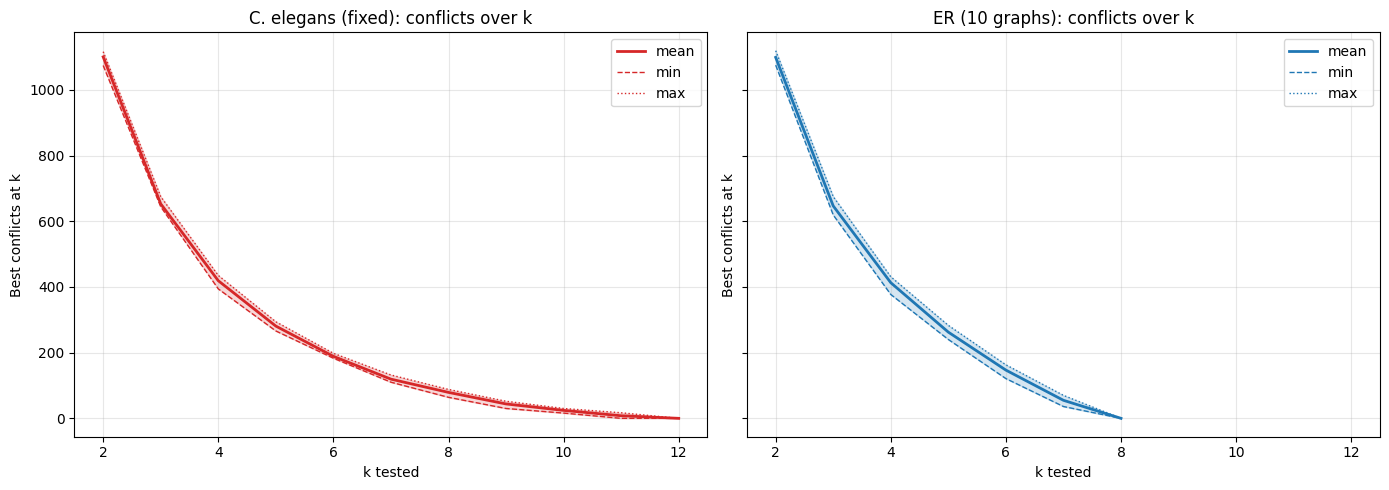

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)

worm_k = [d["k"] for d in worm_summary["per_k_stats"]]
worm_min = [d["min"] for d in worm_summary["per_k_stats"]]
worm_mean = [d["mean"] for d in worm_summary["per_k_stats"]]
worm_max = [d["max"] for d in worm_summary["per_k_stats"]]

er_k = [d["k"] for d in er_agg["per_k_stats"]]
er_min = [d["min"] for d in er_agg["per_k_stats"]]
er_mean = [d["mean"] for d in er_agg["per_k_stats"]]
er_max = [d["max"] for d in er_agg["per_k_stats"]]

axes[0].fill_between(worm_k, worm_min, worm_max, color="tab:red", alpha=0.18)
axes[0].plot(worm_k, worm_mean, color="tab:red", linewidth=2, label="mean")
axes[0].plot(
    worm_k, worm_min, color="tab:red", linestyle="--", linewidth=1, label="min"
)
axes[0].plot(worm_k, worm_max, color="tab:red", linestyle=":", linewidth=1, label="max")
axes[0].set_title("C. elegans (fixed): conflicts over k")
axes[0].set_xlabel("k tested")
axes[0].set_ylabel("Best conflicts at k")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].fill_between(er_k, er_min, er_max, color="tab:blue", alpha=0.18)
axes[1].plot(er_k, er_mean, color="tab:blue", linewidth=2, label="mean")
axes[1].plot(er_k, er_min, color="tab:blue", linestyle="--", linewidth=1, label="min")
axes[1].plot(er_k, er_max, color="tab:blue", linestyle=":", linewidth=1, label="max")
axes[1].set_title("ER (10 graphs): conflicts over k")
axes[1].set_xlabel("k tested")
axes[1].set_ylabel("Best conflicts at k")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

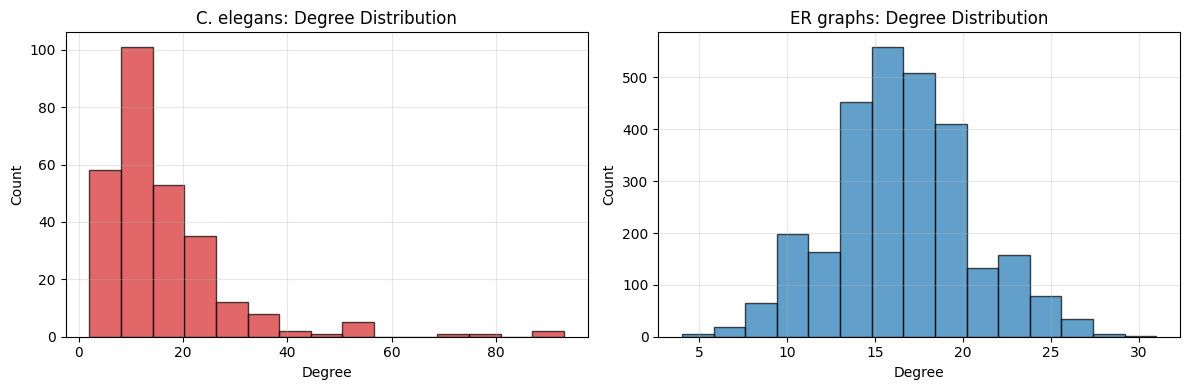

In [ ]:
# degree distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# C.Elegans
worm_degrees = [d for n, d in wormG.degree()]
axes[0].hist(worm_degrees, bins=15, color="tab:red", alpha=0.7, edgecolor="black")
axes[0].set_title("C. elegans: Degree Distribution")
axes[0].set_xlabel("Degree")
axes[0].set_ylabel("Count")
axes[0].grid(True, alpha=0.3)

# average ER graph
er_degrees = []
for g in er_graphs:
    er_degrees.extend([d for n, d in g.degree()])

axes[1].hist(er_degrees, bins=15, color="tab:blue", alpha=0.7, edgecolor="black")
axes[1].set_title("ER graphs: Degree Distribution")
axes[1].set_xlabel("Degree")
axes[1].set_ylabel("Count")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()a

In [7]:
# clustering coefficients
worm_clustering = nx.average_clustering(wormG)
er_clustering_values = [nx.average_clustering(g) for g in er_graphs]
er_clustering_mean = sum(er_clustering_values) / len(er_clustering_values)

print("Clustering Coefficients:")
print(f"C. elegans: {round(worm_clustering, 4)}")
print(f"ER average: {round(er_clustering_mean, 4)}")

Clustering Coefficients:
C. elegans: 0.3371
ER average: 0.0582


In [8]:
# diameter and radius
worm_diameter = nx.diameter(wormG)
worm_radius = nx.radius(wormG)

er_diameters = []
er_radii = []
for g in er_graphs:
    if nx.is_connected(g):
        er_diameters.append(nx.diameter(g))
        er_radii.append(nx.radius(g))
    else:
        largest_cc = max(nx.connected_components(g), key=len)
        subgraph = g.subgraph(largest_cc)
        er_diameters.append(nx.diameter(subgraph))
        er_radii.append(nx.radius(subgraph))

print("\nDiameters:")
print(f"C. elegans: {worm_diameter}")
print(f"ER average: {round(sum(er_diameters) / len(er_diameters), 2)}")

print("\nRadii:")
print(f"C. elegans: {worm_radius}")
print(f"ER average: {round(sum(er_radii) / len(er_radii), 2)}")


Diameters:
C. elegans: 5
ER average: 3.9

Radii:
C. elegans: 3
ER average: 3.0
